In [ ]:
import sys
sys.path.append('..')
import myrfecv as mr
import myfunction as mf
import pandas as pd
import numpy as np

path_data_raw = "C:/Users/dell/OneDrive/file/"
path_country_nc = "C:/Users/dell/OneDrive/file/nc"
path_onedrive_csv = "C:/Users/dell/OneDrive/file/csv/"
path_one_spdb = 'C:/Users/dell/OneDrive/file/SPDB/'
drive_letter = 'E:'

path_pre = drive_letter + "/wyy/code_project/running_outcome/final_data/SPDB/part0_treat/pretreatment/"
path_match = drive_letter + "/wyy/code_project/running_outcome/final_data/SPDB/part0_treat/match/"

path_2_preanalysis_data = drive_letter + "/wyy/code_project/running_outcome/final_data/SPDB/part2_analysis/preanalysis/"


path_temp = drive_letter + "/wyy/code_project/running_outcome/final_data/SPDB/part3_forecast/temp/"


meta_name = "meta_data.csv"

list_pfas = ['PFBS', 'PFDA', 'PFHpA', 'PFHxA', 'PFHxS', 'PFNA', 'PFOA', 
             'PFOS', 'FOSA', 'PFDoDA', 'PFTeDA', 'PFUnDA', 'PFTrDA', 
             'HFPO-DA', 'PFBA', 'PFDS', 'PFHpS', 'PFNS', 'PFPeA', 'PFPeS']

In [2]:
scoring = 'r2'
str_describe = 'sw'

df_sw_data_raw = pd.read_csv(path_match + "sw_match_treat.csv")
print(list_pfas)
df_sw_data_raw = df_sw_data_raw[df_sw_data_raw['posname'].isin(list_pfas)]
df_sw_data_raw['year'] = (df_sw_data_raw['year'] - 2000) / (2020 - 2000)
columns_to_drop = ['lon_grid', 'lat_grid', 'posname']
df_sw_data = df_sw_data_raw.drop(columns=columns_to_drop)

print(df_sw_data.columns)

path_sw_rfecv_data = drive_letter + '/wyy/code_project/running_outcome/final_data/SPDB/part3_forecast/sw_forecast/'
path_sw_rfecv_fig = drive_letter + '/wyy/code_project/running_outcome/final_fig/SPDB/part3_forecast/sw_forecast/'


['PFBS', 'PFDA', 'PFHpA', 'PFHxA', 'PFHxS', 'PFNA', 'PFOA', 'PFOS', 'FOSA', 'PFDoDA', 'PFTeDA', 'PFUnDA', 'PFTrDA', 'HFPO-DA', 'PFBA', 'PFDS', 'PFHpS', 'PFNS', 'PFPeA', 'PFPeS']
Index(['sshf', 'SWD_INC_CO2_E', 'log_Kaw', 'lict', 'HCFC', 'density', 'sp',
       'paper_consumption', 'ltlt', 'global_salinity', 'TOTALS_CO2_E', 'dl',
       'log_Koa_wet', 'licd', 'z', 'solubility', 'tcsw', 'skt', 'C2F6', 'cfc',
       'logPx', 'tp', 'ssro', 'night_lights', 'po_m_w', 'SF6', 'po_chain',
       'log_pKa', 'i10fg', 'population', 'log_KHxd_air', 'GDP',
       'wrap_consumption', 'value', 'sro', 'cl', 'year', 'logD5_5',
       'po_f_carbon', 'fluorite_consumption', 'log_Koc', 'po_carbon', 'ssr',
       'stl1', 'TNR_Ship_CO2_E', 'swvl1', 'cth', 'HFC', 'e', 'si10', 'ctp',
       'nships_smoothed', 'tcrw', 'logD7_4', 'str', 'CF4', 'ctt'],
      dtype='object')


In [15]:
print(df_sw_data_raw['posname'].unique().tolist())
print(len(df_sw_data_raw['posname'].unique().tolist()))

['PFBS', 'PFDA', 'PFHpA', 'PFHxA', 'PFHxS', 'PFNA', 'PFOA', 'PFOS', 'FOSA', 'PFDoDA', 'PFTeDA', 'PFUnDA', 'PFTrDA', 'HFPO-DA', 'PFBA', 'PFDS', 'PFHpS', 'PFNS', 'PFPeA', 'PFPeS']
20


### 函数准备

### RFECV+超参寻找

GBDT Optimal number of features: 45
RF Optimal number of features: 41
LGBM Optimal number of features: 45


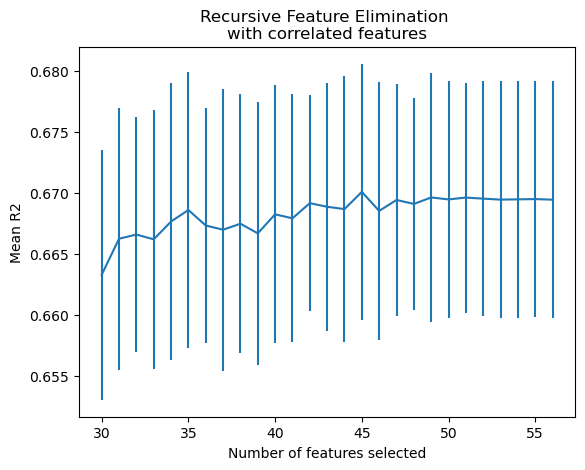

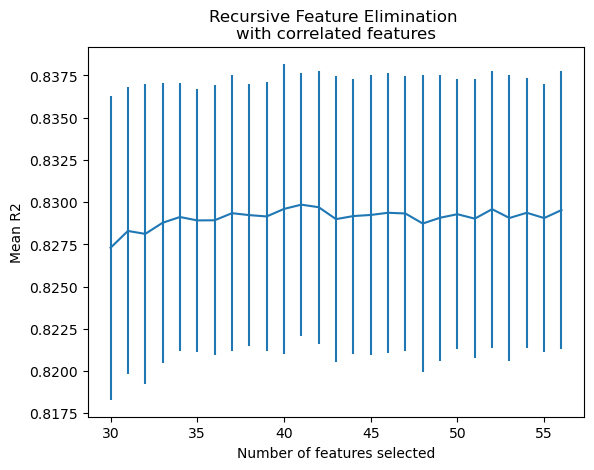

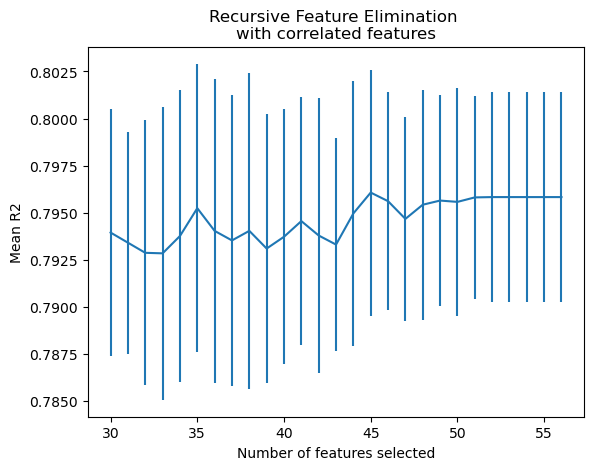

In [ ]:

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from lightgbm import LGBMRegressor



dict_clf = {
    'GBDT': GradientBoostingRegressor(random_state=202406),
    'RF': RandomForestRegressor(random_state=202406),
    'LGBM': LGBMRegressor(random_state=202406)
}

for key, clf in dict_clf.items():
    mr.start_rfecv(key, clf, df_sw_data, str_describe, path_sw_rfecv_data, path_sw_rfecv_fig, 'cv')



In [ ]:
df_lgbm = pd.read_csv(path_sw_rfecv_data + 'sw_rfecv_features_LGBMcv.csv')

df_lgbm['Importance'] = df_lgbm['Importance'] / df_lgbm['Importance'].sum()

df_lgbm.to_csv(path_sw_rfecv_data + 'sw_rfecv_features_LGBMcv.csv', index=False)

In [ ]:
import pandas as pd
df_sw_rf_rfecv = pd.read_csv(path_sw_rfecv_data + 'sw_rfecv_r2_RFcv.csv')
df_sw_rf_rfecv['model'] = 'RF'
df_sw_gbdt_rfecv = pd.read_csv(path_sw_rfecv_data + 'sw_rfecv_r2_GBDTcv.csv')
df_sw_gbdt_rfecv['model'] = 'GBDT'
df_sw_lgbm_rfecv = pd.read_csv(path_sw_rfecv_data + 'sw_rfecv_r2_LGBMcv.csv')
df_sw_lgbm_rfecv['model'] = 'LGBM'
df_sw_rfecv = pd.concat([df_sw_rf_rfecv,df_sw_gbdt_rfecv, df_sw_lgbm_rfecv],axis=0)

df_sw_rfecv = df_sw_rfecv.sort_values(by='mean_test_score', ascending=False)

max_index = df_sw_rfecv['mean_test_score'].idxmax()
min_features = df_sw_rfecv.loc[max_index, 'min_features'].tolist()[0]
max_model = df_sw_rfecv.loc[max_index, 'model'].tolist()[0]
max_score = round(df_sw_rfecv.loc[max_index, 'mean_test_score'].tolist()[0],3)
df_sw_rfecv.to_csv(path_sw_rfecv_data + 'sw_merge_rfecv.csv',index=False)
print(f'model:{max_model} min_feature:{min_features} score:{max_score}')

model:RF min_feature:41 score:0.83


In [ ]:
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
model_configs = {
        'RF': {
            'model_class': RandomForestRegressor,
            'param_grid': {
                'n_estimators': [200, 300],
                'max_depth': [None,10],
                'min_samples_split': [2, 4, 6],
                'min_samples_leaf': [1, 2, 3],
            }
        },
        'GBDT': {
            'model_class': GradientBoostingRegressor,
            'param_grid': {
                'n_estimators': [200, 300],
                'learning_rate': [0.1],
                'max_depth': [None,10],
                'min_samples_split': [2, 4, 6],
                'min_samples_leaf': [1, 2, 3],
            }
        },
        'LGBM': {
            'model_class': LGBMRegressor,
            'fixed_params': {'verbose': -1}, 
            'param_grid': {
                'n_estimators': [200, 300],
                'learning_rate': [0.1],
                'max_depth': [None, 10],
                'num_leaves': [31, 63, 127],
                'min_child_samples': [1, 2, 3]
            }
        }
    }


cv_result = mr.grid_search_param(
    df_sw_data, 
    str_describe, 
    scoring, 
    path_sw_rfecv_data, 
    model_configs, 
    'cv'
)


cv_result.to_csv(path_sw_rfecv_data + 'ml_cv_results.csv', index=False)

sw RF
Best parameters for RF: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
sw GBDT
Best parameters for GBDT: {'learning_rate': 0.1, 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 6, 'n_estimators': 300}
sw LGBM
Best parameters for LGBM: {'learning_rate': 0.1, 'max_depth': None, 'min_child_samples': 3, 'n_estimators': 300, 'num_leaves': 127}


In [12]:
cv_result = pd.read_csv(path_sw_rfecv_data + 'ml_cv_results.csv')
results = mr.get_tree_best_model(cv_result)
results.to_csv(path_sw_rfecv_data + 'ml_cv_best.csv', index=False)
results = pd.read_csv(path_sw_rfecv_data + 'ml_cv_best.csv')
for index, value in results['param_max_depth'].items():
    if pd.isna(value) or value == '':
        results.at[index, 'param_max_depth'] = 'None'
results.to_csv(path_sw_rfecv_data + 'ml_cv_best.csv', index=False)

In [ ]:

df_sw_rf_rfecv = pd.read_csv(path_sw_rfecv_data + 'sw_rfecv_r2_RFcv.csv')
df_sw_rf_rfecv['model'] = 'RF'
df_sw_gbdt_rfecv = pd.read_csv(path_sw_rfecv_data + 'sw_rfecv_r2_GBDTcv.csv')
df_sw_gbdt_rfecv['model'] = 'GBDT'
df_sw_lgbm_rfecv = pd.read_csv(path_sw_rfecv_data + 'sw_rfecv_r2_LGBMcv.csv')
df_sw_lgbm_rfecv['model'] = 'LGBM'

df_sw_rfecv = pd.concat([df_sw_rf_rfecv,df_sw_gbdt_rfecv, df_sw_lgbm_rfecv],axis=0)
df_sw_rfecv = df_sw_rfecv.sort_values(by='mean_test_score', ascending=False)
print(df_sw_rfecv.head())
max_index = df_sw_rfecv['mean_test_score'].idxmax()
min_features = df_sw_rfecv.loc[max_index, 'min_features'].tolist()[0]
max_model = df_sw_rfecv.loc[max_index, 'model'].tolist()[0]
max_score = round(df_sw_rfecv.loc[max_index, 'mean_test_score'].tolist()[0],3)
df_sw_rfecv.to_csv(path_sw_rfecv_data + 'sw_merge_rfecv.csv',index=False)
print(f'model:{max_model} min_feature:{min_features} score:{max_score}')

### 未知PFAS

In [ ]:
scoring = 'r2'
str_describe = 'sw'


path_sw_rfecv_data = drive_letter + '/wyy/code_project/running_outcome/final_data/SPDB/part3_forecast/sw_forecast/'

df_sw_sem_all = pd.read_csv(path_match + 'sw_match_treat.csv')
df_sw_sem_all['year'] = (df_sw_sem_all['year'] - 2000) / (2020 - 2000)

best_params = pd.read_csv(path_sw_rfecv_data + 'ml_cv_best.csv')
best_params = best_params.sort_values(by='mean_test_score', ascending=False)

df_sw_select_train = df_sw_sem_all[df_sw_sem_all['posname'].isin(list_pfas)]
df_sw_select_test = df_sw_sem_all[~df_sw_sem_all['posname'].isin(list_pfas)]

mark_num = 'cv'

selected_features_lgbm = pd.read_csv(path_sw_rfecv_data + str_describe + "_rfecv_features_LGBM"+mark_num+".csv")
selected_features_lgbm = selected_features_lgbm[selected_features_lgbm["Rank"] == 1]["Feature"].values

lgbm_params = best_params[best_params["model"] == "LGBM"].iloc[0]
param_max_depth = None if lgbm_params["param_max_depth"] == 'None' else int(float(lgbm_params["param_max_depth"]))


X_train = df_sw_select_train[selected_features_lgbm]
y_train = df_sw_select_train['value']
X_test = df_sw_select_test[selected_features_lgbm]
y_test = df_sw_select_test['value']


lgbm = LGBMRegressor(
    n_estimators=int(lgbm_params["param_n_estimators"]),
    learning_rate=lgbm_params["param_learning_rate"],
    max_depth=param_max_depth,
    num_leaves=int(lgbm_params["param_num_leaves"]),
    min_child_samples=int(lgbm_params["param_min_child_samples"]),
    random_state=202503
)

lgbm.fit(X_train, y_train)

y_pred = lgbm.predict(X_test)

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Random Forest Model Evaluation:")
print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")


results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})
results_df['Residuals'] = results_df['Actual'] - results_df['Predicted']


Random Forest Model Evaluation:
R2 Score: 0.7763
RMSE: 0.4916
